# Architecture Comparison – Embryo Health Prediction
Loads `results/{arch}/evaluation_report.json` for all trained architectures and produces a comparison table + bar charts.

In [1]:
import os, json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

RESULTS_DIR = '../results'
METRICS = ['accuracy','balanced_accuracy','macro_f1','mcc','roc_auc','pr_auc','inference_speed_ms']

records = []
for arch in os.listdir(RESULTS_DIR):
    rpt = os.path.join(RESULTS_DIR, arch, 'evaluation_report.json')
    if not os.path.exists(rpt): continue
    with open(rpt) as f: data = json.load(f)
    row = {'architecture': arch}
    row.update({k: data['metrics'].get(k) for k in METRICS})
    records.append(row)

df = pd.DataFrame(records).set_index('architecture').sort_values('accuracy', ascending=False)
print(df.to_string())

                 accuracy  balanced_accuracy  macro_f1       mcc   roc_auc    pr_auc  inference_speed_ms
architecture                                                                                            
resnet152        0.981074           0.980650  0.981002  0.962093  0.997947  0.997999              0.2036
resnet50         0.973003           0.971835  0.972852  0.946473  0.995404  0.995466              0.1173
densenet121      0.969942           0.968443  0.969746  0.940780  0.995280  0.995400              0.3043
efficientnet_b0  0.968272           0.967503  0.968128  0.936549  0.996136  0.995989              0.1687
resnet18         0.966323           0.965074  0.966129  0.933110  0.996211  0.996144              0.0912
densenet201      0.965488           0.964405  0.965305  0.931230  0.994836  0.994789              0.3707
resnet101        0.962984           0.961142  0.962706  0.927346  0.995423  0.995428              0.1405
vgg19            0.957696           0.955823  0.957376 

In [2]:
# Highlight best per metric
styled = df.style.highlight_max(axis=0, subset=['accuracy','balanced_accuracy','macro_f1','mcc','roc_auc','pr_auc'],
                                color='#10b981') \
                 .highlight_min(axis=0, subset=['inference_speed_ms'], color='#10b981')
styled

,accuracy,balanced_accuracy,macro_f1,mcc,roc_auc,pr_auc,inference_speed_ms
architecture,,,,,,,
resnet152,0.981074,0.980650,0.981002,0.962093,0.997947,0.997999,0.203600
resnet50,0.973003,0.971835,0.972852,0.946473,0.995404,0.995466,0.117300
densenet121,0.969942,0.968443,0.969746,0.940780,0.995280,0.995400,0.304300
efficientnet_b0,0.968272,0.967503,0.968128,0.936549,0.996136,0.995989,0.168700
resnet18,0.966323,0.965074,0.966129,0.933110,0.996211,0.996144,0.091200
densenet201,0.965488,0.964405,0.965305,0.931230,0.994836,0.994789,0.370700
resnet101,0.962984,0.961142,0.962706,0.927346,0.995423,0.995428,0.140500
vgg19,0.957696,0.955823,0.957376,0.916710,0.994008,0.993964,0.028900
mobilenet_v2,0.949624,0.947253,0.949164,0.901480,0.992533,0.992502,0.113400


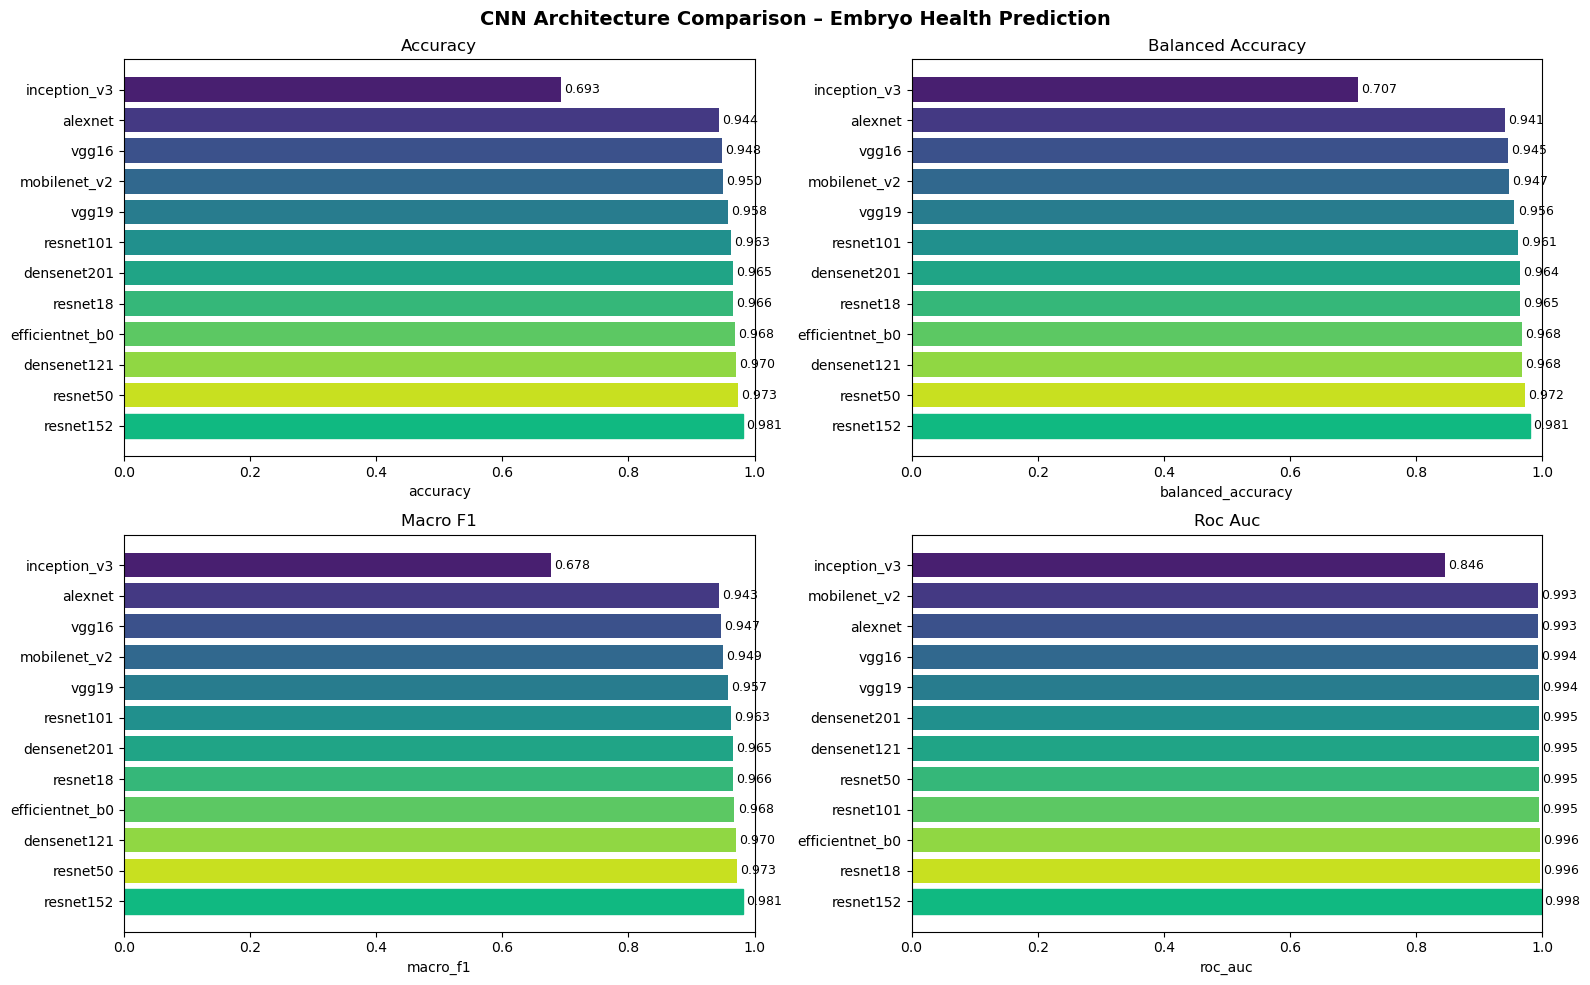

In [3]:
# Bar charts per metric
plot_metrics = ['accuracy','balanced_accuracy','macro_f1','roc_auc']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
colors = plt.cm.viridis_r([i/len(df) for i in range(len(df))])

for ax, metric in zip(axes.flat, plot_metrics):
    vals = df[metric].sort_values(ascending=False)
    bars = ax.barh(vals.index, vals.values, color=colors)
    bars[0].set_color('#10b981')   # highlight best
    ax.set_xlabel(metric)
    ax.set_title(metric.replace('_',' ').title())
    ax.set_xlim(0, 1)
    for bar, val in zip(bars, vals.values):
        ax.text(val + 0.005, bar.get_y()+bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('CNN Architecture Comparison – Embryo Health Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/architecture_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

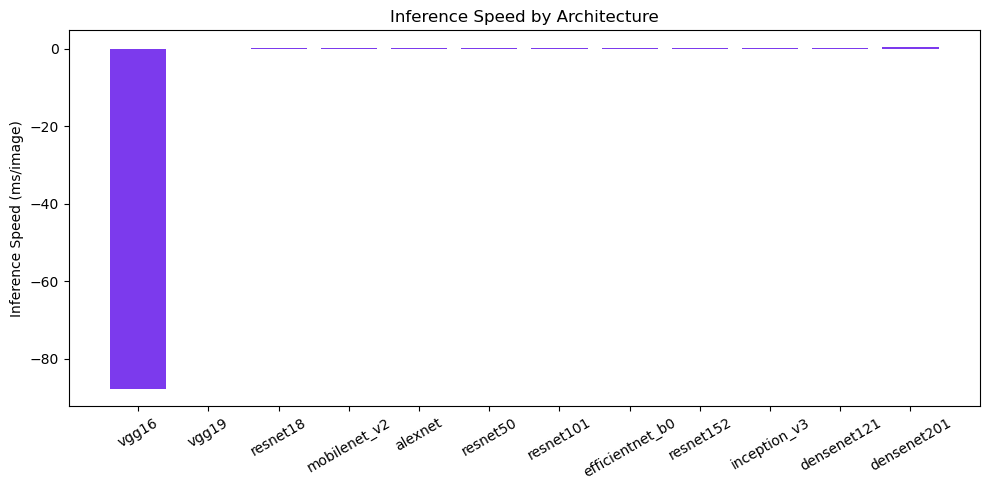

In [4]:
# Inference speed comparison
fig, ax = plt.subplots(figsize=(10, 5))
spd = df['inference_speed_ms'].sort_values()
ax.bar(spd.index, spd.values, color='#7c3aed')
ax.set_ylabel('Inference Speed (ms/image)')
ax.set_title('Inference Speed by Architecture')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()